# Demand Prediction and Congestion Modeling

**Focus:** Training and evaluating machine learning models to forecast station energy demand and utilization rates.

**Models:** XGBoost (gradient boosting) + LightGBM (gradient boosting) + Random Forest (ensemble baseline)

**Metrics:** RMSE, MAE, R² Score

In [11]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.config import *
from src.utils import *
from src.demand_agent import DemandPredictionAgent, run_demand_prediction

setup_plot_style()

## Loading Engineered Features

In [12]:
df = load_csv(FEATURES_CSV)
print(f"Dataset shape: {df.shape}")

# Show available features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric features available: {len(numeric_cols)}")
for c in numeric_cols:
    print(f"  {c}: non-null={df[c].notna().sum()}, mean={df[c].mean():.3f}")

2026-05-30 23:54:02 | utils                     | INFO    | Loading CSV: c:\Users\USER\Desktop\Proj\notebooks\..\data\processed\features_engineered.csv
2026-05-30 23:54:05 | utils                     | INFO    |   → Shape: (192731, 36) | Columns: ['station_id', 'timestamp', 'session_count', 'total_energy_kwh', 'avg_energy_kwh', 'avg_duration_min', 'avg_charging_min', 'charger_utilization_rate', 'energy_kwh', 'data_source', 'volume_kwh', 'active_chargers', 'price_per_kwh', 'total_chargers', 'is_cbd', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'day_of_month', 'time_period', 'revenue_per_session', 'energy_cost_per_kwh', 'queue_length_proxy', 'occupancy_density', 'demand_lag_1', 'demand_lag_2', 'demand_lag_6', 'demand_lag_24', 'energy_rolling_1h', 'energy_rolling_6h', 'energy_rolling_24h', 'charger_rolling_1h', 'charger_rolling_6h', 'charger_rolling_24h']


Dataset shape: (192731, 36)

Numeric features available: 32
  session_count: non-null=14891, mean=1.007
  total_energy_kwh: non-null=14891, mean=9.068
  avg_energy_kwh: non-null=14891, mean=9.032
  avg_duration_min: non-null=192731, mean=28.951
  avg_charging_min: non-null=14891, mean=194.919
  charger_utilization_rate: non-null=192731, mean=0.331
  energy_kwh: non-null=192731, mean=406.835
  volume_kwh: non-null=177840, mean=440.141
  active_chargers: non-null=177840, mean=21.902
  price_per_kwh: non-null=177840, mean=0.959
  total_chargers: non-null=177840, mean=73.121
  is_cbd: non-null=177840, mean=0.251
  hour_of_day: non-null=192731, mean=11.628
  day_of_week: non-null=192731, mean=2.976
  is_weekend: non-null=192731, mean=0.291
  is_peak_hour: non-null=192731, mean=0.325
  month: non-null=192731, mean=6.715
  day_of_month: non-null=192731, mean=15.530
  revenue_per_session: non-null=192731, mean=6102.529
  energy_cost_per_kwh: non-null=192731, mean=15.000
  queue_length_proxy: n

## Initializing Agent and Splitting Dataset (Chronological Split)

In [13]:
agent = DemandPredictionAgent()

# Use energy_kwh as target (available for both ACN and UrbanEV)
target_col = "energy_kwh"
X_train, X_val, X_test, y_train, y_val, y_test = agent.prepare_data(
    df, target_col=target_col
)

print(f"\nFeatures used ({len(agent.feature_columns)}):")
for f in agent.feature_columns:
    print(f"  • {f}")

2026-05-30 23:54:05 | utils                     | INFO    | Random seed set to 42
2026-05-30 23:54:05 | demand_agent              | INFO    | Preparing data for demand prediction...
2026-05-30 23:54:05 | demand_agent              | INFO    |   Using 15 features: ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'day_of_month', 'charger_utilization_rate', 'revenue_per_session', 'energy_cost_per_kwh', 'queue_length_proxy']...
2026-05-30 23:54:05 | demand_agent              | INFO    |   Clean samples: 185541 (dropped 7190 NaN rows)
2026-05-30 23:54:05 | demand_agent              | INFO    |   Split → Train: 129878 | Val: 27831 | Test: 27832



Features used (15):
  • hour_of_day
  • day_of_week
  • is_weekend
  • is_peak_hour
  • month
  • day_of_month
  • charger_utilization_rate
  • revenue_per_session
  • energy_cost_per_kwh
  • queue_length_proxy
  • occupancy_density
  • demand_lag_1
  • demand_lag_2
  • demand_lag_6
  • demand_lag_24


## XGBoost Regressor Training

In [14]:
xgb_model = agent.train_xgboost(X_train, y_train, X_val, y_val)

# Evaluate
xgb_metrics = agent.evaluate(X_test, y_test, "xgboost")
print(f"\nXGBoost Results:")
for k, v in xgb_metrics.items():
    if k != "model":
        print(f"  {k}: {v:.4f}")

2026-05-30 23:54:06 | demand_agent              | INFO    | Training XGBoost model...


[0]	validation_0-rmse:732.61209
[50]	validation_0-rmse:61.64052
[100]	validation_0-rmse:35.76140
[150]	validation_0-rmse:34.23465
[200]	validation_0-rmse:33.78888
[250]	validation_0-rmse:33.31260
[300]	validation_0-rmse:32.83757
[350]	validation_0-rmse:32.43388
[400]	validation_0-rmse:32.22091
[450]	validation_0-rmse:31.97665
[499]	validation_0-rmse:31.79855


2026-05-30 23:54:23 | demand_agent              | INFO    |   XGBoost training complete ✓
2026-05-30 23:54:23 | demand_agent              | INFO    | Evaluating xgboost...
2026-05-30 23:54:23 | utils                     | INFO    |   Regression Metrics → RMSE: 30.5595 | MAE: 9.3220 | R²: 0.9982



XGBoost Results:
  RMSE: 30.5595
  MAE: 9.3220
  R2: 0.9982


## Random Forest Regressor Baseline

In [15]:
rf_model = agent.train_random_forest(X_train, y_train)

# Evaluate
rf_metrics = agent.evaluate(X_test, y_test, "random_forest")
print(f"\nRandom Forest Results:")
for k, v in rf_metrics.items():
    if k != "model":
        print(f"  {k}: {v:.4f}")

2026-05-30 23:54:23 | demand_agent              | INFO    | Training Random Forest model...
2026-05-30 23:56:57 | demand_agent              | INFO    |   Random Forest training complete ✓
2026-05-30 23:56:57 | demand_agent              | INFO    | Evaluating random_forest...
2026-05-30 23:56:57 | utils                     | INFO    |   Regression Metrics → RMSE: 0.3722 | MAE: 0.2152 | R²: 1.0000



Random Forest Results:
  RMSE: 0.3722
  MAE: 0.2152
  R2: 1.0000


## LightGBM Regressor Training

In [16]:
lgb_model = agent.train_lightgbm(X_train, y_train, X_val, y_val)

# Evaluate
lgb_metrics = agent.evaluate(X_test, y_test, "lightgbm")
print(f"\nLightGBM Results:")
for k, v in lgb_metrics.items():
    if k != "model":
        print(f"  {k}: {v:.4f}")

2026-05-30 23:56:57 | demand_agent              | INFO    | Training LightGBM model...
2026-05-30 23:57:05 | demand_agent              | INFO    |   LightGBM training complete ✓
2026-05-30 23:57:05 | demand_agent              | INFO    | Evaluating lightgbm...
2026-05-30 23:57:06 | utils                     | INFO    |   Regression Metrics → RMSE: 28.0471 | MAE: 7.9250 | R²: 0.9985



LightGBM Results:
  RMSE: 28.0471
  MAE: 7.9250
  R2: 0.9985


## Regression Performance Metrics Comparison

In [17]:
results = agent.evaluate_all_models(X_test, y_test)
print("\n" + "=" * 50)
print("  MODEL COMPARISON")
print("=" * 50)
print(results.to_string(index=False))

# Save metrics
save_csv(results, OUTPUTS_DIR / "demand_metrics.csv")

# Best model
best = results.sort_values("RMSE").iloc[0]
print(f"\n🏆 Best Model: {best['model']} (RMSE: {best['RMSE']:.4f}, R²: {best['R2']:.4f})")

2026-05-30 23:57:06 | demand_agent              | INFO    | Evaluating xgboost...
2026-05-30 23:57:06 | utils                     | INFO    |   Regression Metrics → RMSE: 30.5595 | MAE: 9.3220 | R²: 0.9982
2026-05-30 23:57:06 | demand_agent              | INFO    | Evaluating random_forest...
2026-05-30 23:57:07 | utils                     | INFO    |   Regression Metrics → RMSE: 0.3722 | MAE: 0.2152 | R²: 1.0000
2026-05-30 23:57:07 | demand_agent              | INFO    | Evaluating lightgbm...
2026-05-30 23:57:08 | utils                     | INFO    |   Regression Metrics → RMSE: 28.0471 | MAE: 7.9250 | R²: 0.9985
2026-05-30 23:57:08 | demand_agent              | INFO    | 
  Model Comparison:
        RMSE       MAE        R2          model
0  30.559517  9.322014  0.998195        xgboost
1   0.372151  0.215228  1.000000  random_forest
2  28.047087  7.925027  0.998479       lightgbm
2026-05-30 23:57:08 | utils                     | INFO    | Saved CSV: c:\Users\USER\Desktop\Proj\noteb


  MODEL COMPARISON
     RMSE      MAE       R2         model
30.559517 9.322014 0.998195       xgboost
 0.372151 0.215228 1.000000 random_forest
28.047087 7.925027 0.998479      lightgbm

🏆 Best Model: random_forest (RMSE: 0.3722, R²: 1.0000)


## Feature Importance Analysis (Tree-based Models)

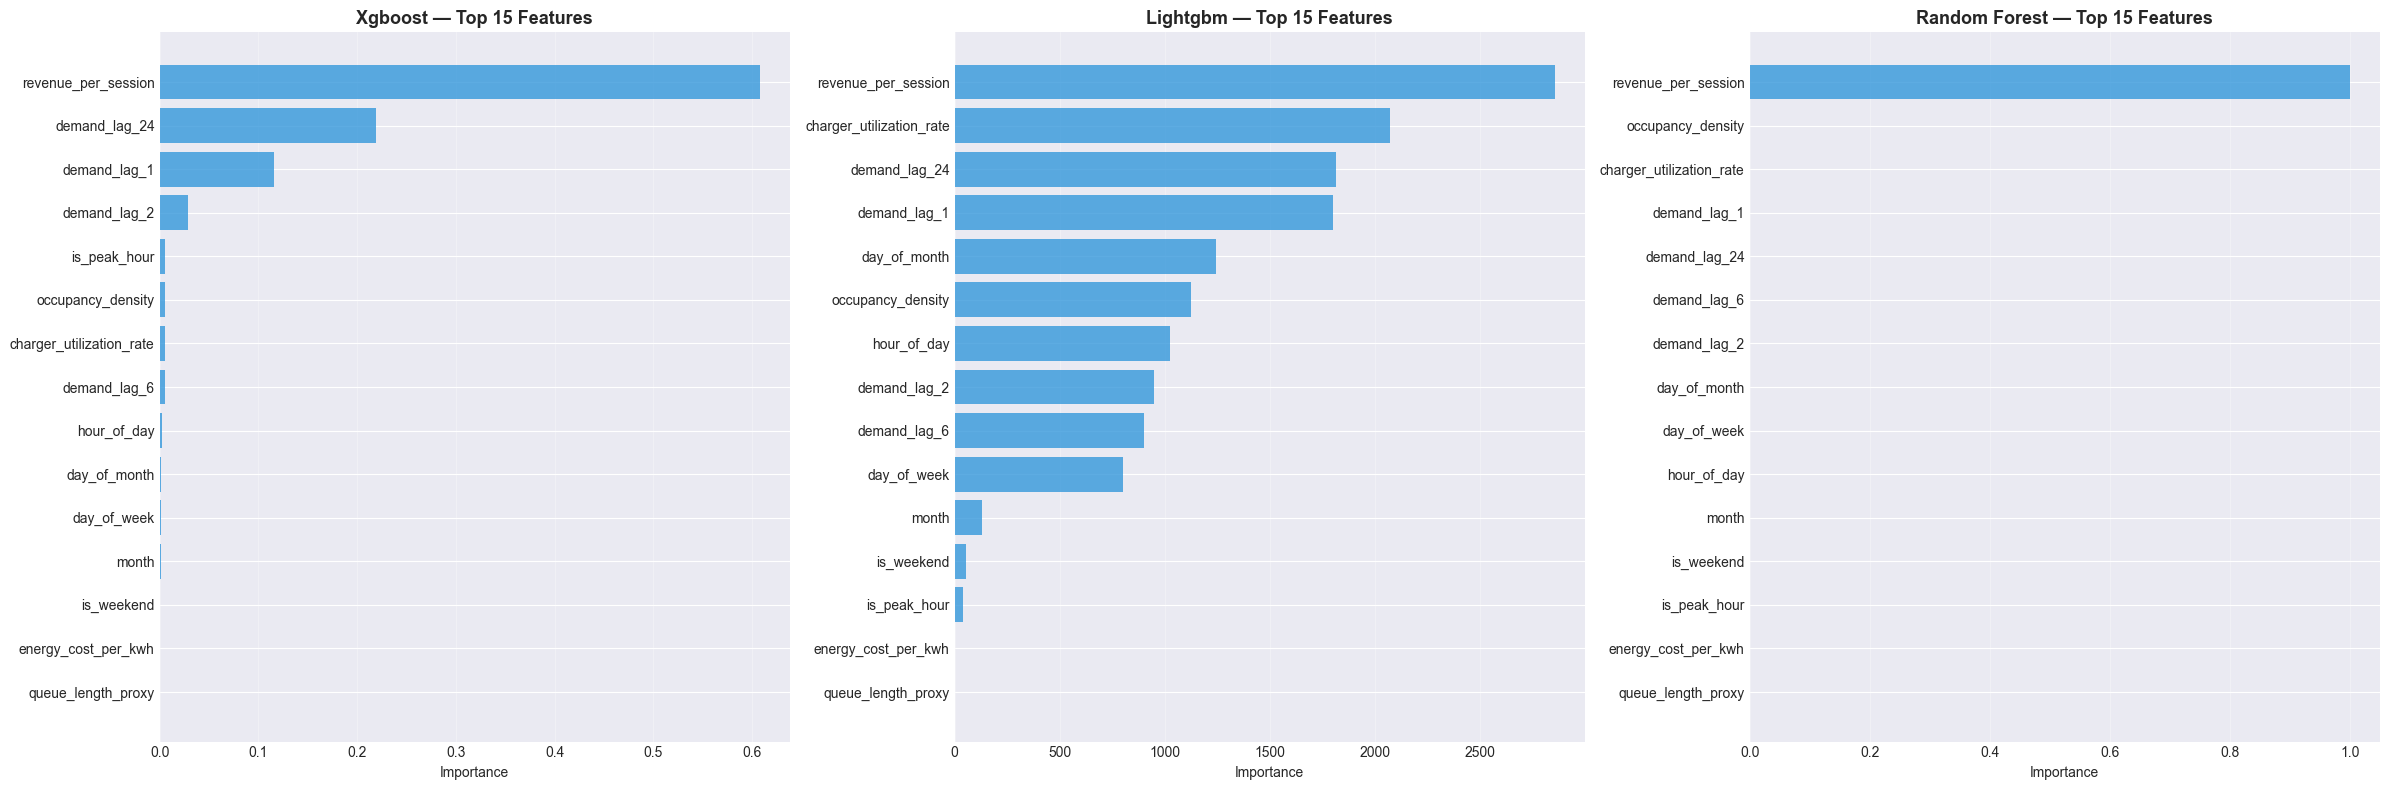

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, model_name in enumerate(["xgboost", "lightgbm", "random_forest"]):
    importance = agent.get_feature_importance(model_name)
    if not importance.empty:
        top_n = importance.head(15)
        axes[i].barh(top_n["feature"], top_n["importance"], color="#3498db", alpha=0.8)
        axes[i].set_title(f"{model_name.replace('_', ' ').title()} — Top 15 Features",
                         fontsize=13, fontweight="bold")
        axes[i].set_xlabel("Importance")
        axes[i].invert_yaxis()
        axes[i].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "demand_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

## Scatter Diagnostics: Predicted vs. Actual Demand

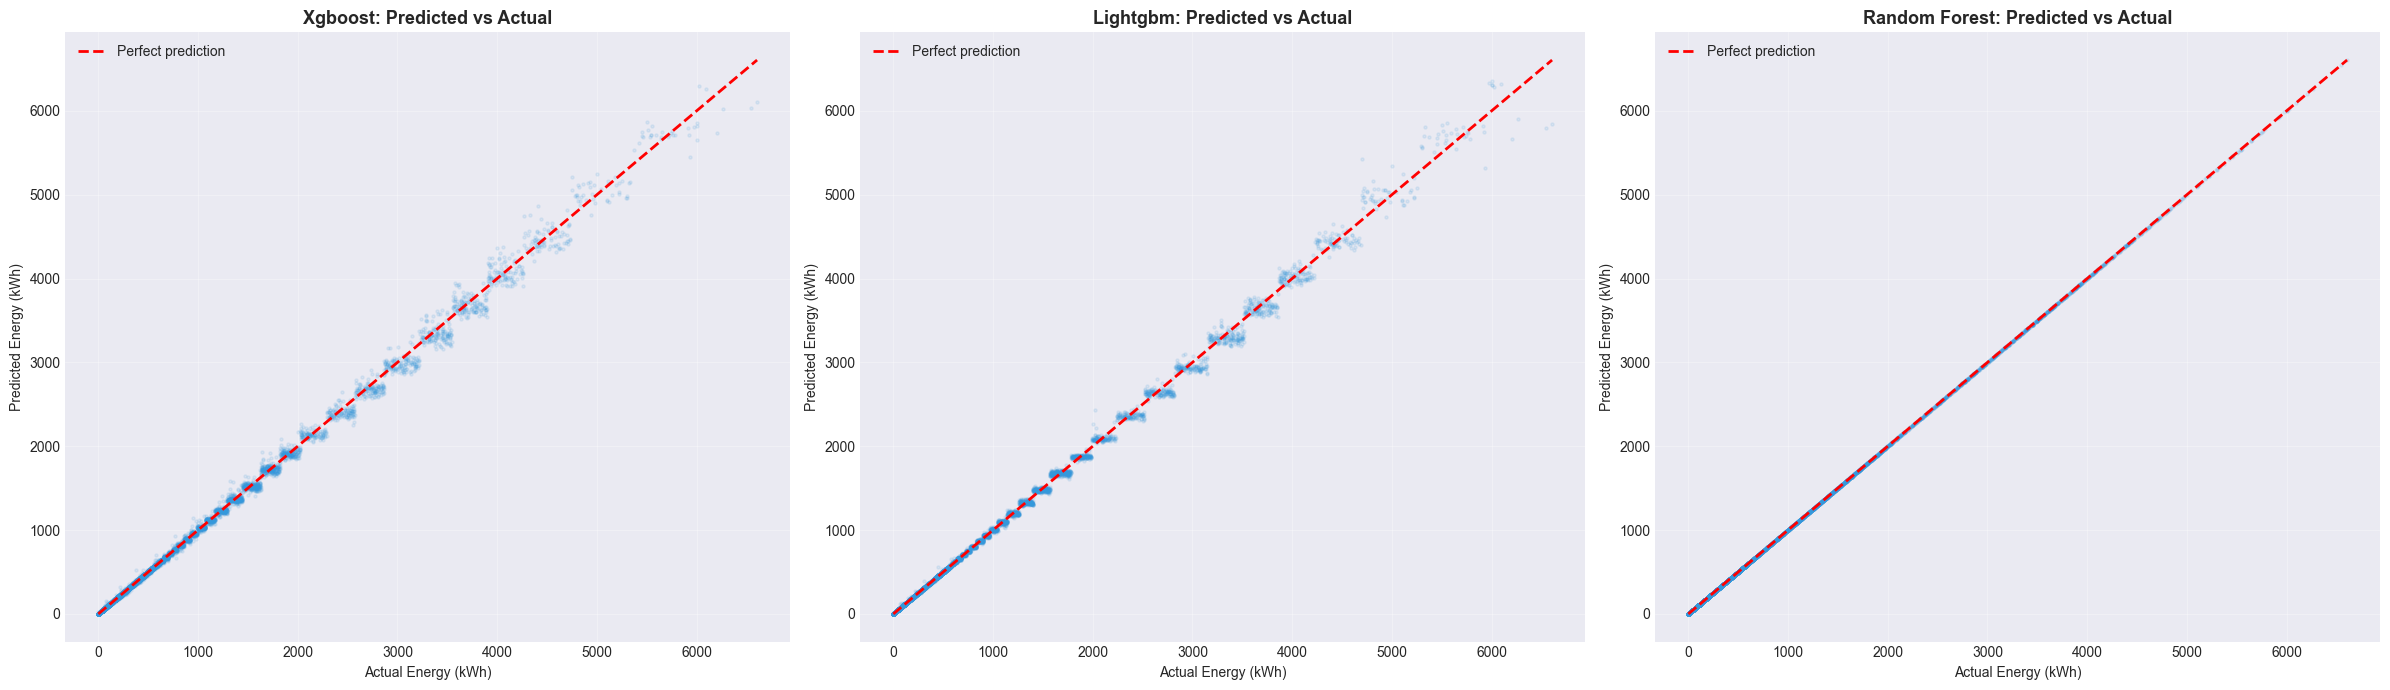

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for i, model_name in enumerate(["xgboost", "lightgbm", "random_forest"]):
    y_pred = agent.predict(X_test, model_name)

    # Scatter plot
    axes[i].scatter(y_test, y_pred, alpha=0.1, s=5, color="#3498db")
    max_val = max(y_test.max(), y_pred.max())
    axes[i].plot([0, max_val], [0, max_val], "r--", lw=2, label="Perfect prediction")
    axes[i].set_title(f"{model_name.replace('_', ' ').title()}: Predicted vs Actual",
                     fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Actual Energy (kWh)")
    axes[i].set_ylabel("Predicted Energy (kWh)")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "demand_prediction_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

## Saving Demand Prediction Model State

In [20]:
agent.save()
print("Demand Prediction Agent saved ✓")
print(f"Models trained: {list(agent.models.keys())}")

2026-05-30 23:57:20 | utils                     | INFO    | Saved model: c:\Users\USER\Desktop\Proj\notebooks\..\models\demand_agent.pkl
2026-05-30 23:57:20 | demand_agent              | INFO    | Demand agent saved as 'demand_agent'


Demand Prediction Agent saved ✓
Models trained: ['xgboost', 'random_forest', 'lightgbm']
